# 06b Physical Feature Ablation (Ridge-only)

This notebook is a **feature-ablation stress test** for fixed discrete-`n` superellipse data.

Scope is intentionally narrow:
- no new data generation,
- no neural networks,
- no new model families,
- Ridge regression only.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.model import evaluate_leave_one_group_out, make_physical_feature_matrix


In [2]:
data_path = PROJECT_ROOT / "data" / "superellipse_discrete_n_dense_dataset.npz"
data = np.load(data_path)

n_all = data["n"].astype(float)
a_all = data["a"].astype(float)
r_all = data["aspect_ratio"].astype(float)

targets = {
    "E0": data["E0"].astype(float),
    "dE1": data["dE1"].astype(float),
}

n_focus = [1.2, 4.0]
feature_sets = ["A", "B", "C"]
protocols = ["LOAO", "LOARO"]

print(f"Loaded: {data_path}")
print(f"Samples: {n_all.size}")
print(f"Available n classes: {np.unique(n_all)}")


Loaded: D:\Diplom Physcis ML\Diplom Physcis ML\data\superellipse_discrete_n_dense_dataset.npz
Samples: 140
Available n classes: [1.2 2.  3.  4. ]


## Pre-declared acceptance criteria (declared before results)

Primary decision axis is **LOAO for E0**:
1. meaningful improvement = lower LOAO MaxAE for E0 relative to Set A,
2. strongest interest = edge-size failures (`a=24` and `a=36`) decrease,
3. secondary interest = LOAO MAE also decreases,
4. LOARO is supportive context only, not the main acceptance axis.


In [3]:
def compact(x: float) -> str:
    return f"{x:.4e}"


def format_table(rows: list[dict[str, object]], cols: list[str]) -> str:
    widths = {c: max(len(c), max(len(str(r[c])) for r in rows)) for c in cols}
    header = " | ".join(c.ljust(widths[c]) for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    lines = [header, sep]
    for row in rows:
        lines.append(" | ".join(str(row[c]).ljust(widths[c]) for c in cols))
    return "\n".join(lines)


results: dict[float, dict[str, dict[str, dict[str, object]]]] = {}
for n_val in n_focus:
    class_mask = np.isclose(n_all, n_val)
    a_class = a_all[class_mask]
    r_class = r_all[class_mask]
    results[n_val] = {}
    for target_name, y_full in targets.items():
        y = y_full[class_mask]
        results[n_val][target_name] = {}
        for fs in feature_sets:
            X = make_physical_feature_matrix(a_class, r_class, feature_set=fs)
            results[n_val][target_name][fs] = {
                "LOAO": evaluate_leave_one_group_out(X, y, a_class, model_name="ridge"),
                "LOARO": evaluate_leave_one_group_out(X, y, r_class, model_name="ridge"),
            }

rows: list[dict[str, object]] = []
for protocol in protocols:
    for n_val in n_focus:
        for target_name in ["E0", "dE1"]:
            for fs in feature_sets:
                overall = results[n_val][target_name][fs][protocol]["overall"]
                rows.append(
                    {
                        "protocol": protocol,
                        "n": f"{n_val:.1f}",
                        "target": target_name,
                        "feature_set": fs,
                        "MAE": compact(float(overall["mae"])),
                        "RMSE": compact(float(overall["rmse"])),
                        "MaxAE": compact(float(overall["max_abs_error"])),
                    }
                )

cols = ["protocol", "n", "target", "feature_set", "MAE", "RMSE", "MaxAE"]
print("LOAO + LOARO compact comparison (Ridge-only):")
print(format_table(rows, cols))


LOAO + LOARO compact comparison (Ridge-only):
protocol | n   | target | feature_set | MAE        | RMSE       | MaxAE     
---------+-----+--------+-------------+------------+------------+-----------
LOAO     | 1.2 | E0     | A           | 1.1042e-03 | 1.3760e-03 | 4.3433e-03
LOAO     | 1.2 | E0     | B           | 5.1091e-04 | 6.8732e-04 | 2.5351e-03
LOAO     | 1.2 | E0     | C           | 1.5824e-04 | 2.2064e-04 | 8.6921e-04
LOAO     | 1.2 | dE1    | A           | 1.3636e-03 | 1.6121e-03 | 4.0374e-03
LOAO     | 1.2 | dE1    | B           | 3.2392e-04 | 4.3403e-04 | 1.6260e-03
LOAO     | 1.2 | dE1    | C           | 3.5680e-04 | 4.8817e-04 | 1.4241e-03
LOAO     | 4.0 | E0     | A           | 7.0994e-04 | 8.7995e-04 | 2.6511e-03
LOAO     | 4.0 | E0     | B           | 3.2131e-04 | 4.2725e-04 | 1.5163e-03
LOAO     | 4.0 | E0     | C           | 1.1533e-04 | 1.4715e-04 | 4.6653e-04
LOAO     | 4.0 | dE1    | A           | 8.2491e-04 | 9.4691e-04 | 1.8562e-03
LOAO     | 4.0 | dE1    | B   

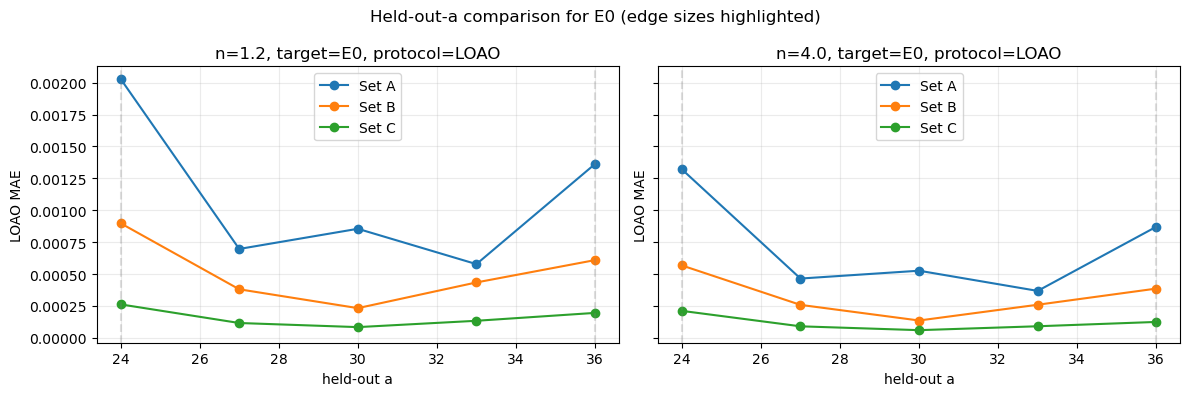

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, n_val in zip(axes, n_focus):
    class_mask = np.isclose(n_all, n_val)
    a_class = a_all[class_mask]

    groups = None
    for fs in feature_sets:
        per_group = results[n_val]["E0"][fs]["LOAO"]["per_group"]
        a_groups = [int(d["group"]) for d in per_group]
        maes = [float(d["mae"]) for d in per_group]
        if groups is None:
            groups = a_groups
        ax.plot(a_groups, maes, marker="o", label=f"Set {fs}")

    ax.set_title(f"n={n_val:.1f}, target=E0, protocol=LOAO")
    ax.set_xlabel("held-out a")
    ax.set_ylabel("LOAO MAE")
    ax.grid(True, alpha=0.25)
    for edge in [24, 36]:
        ax.axvline(edge, color="gray", linestyle="--", alpha=0.25)
    ax.legend()

plt.suptitle("Held-out-a comparison for E0 (edge sizes highlighted)")
plt.tight_layout()
plt.show()


In [5]:
def criteria_summary_for_n(n_val: float) -> dict[str, object]:
    loao_e0 = {
        fs: results[n_val]["E0"][fs]["LOAO"]["overall"] for fs in feature_sets
    }
    loaro_e0 = {
        fs: results[n_val]["E0"][fs]["LOARO"]["overall"] for fs in feature_sets
    }

    maxae_a = float(loao_e0["A"]["max_abs_error"])
    mae_a = float(loao_e0["A"]["mae"])

    improves_maxae = {
        fs: float(loao_e0[fs]["max_abs_error"]) < maxae_a for fs in ["B", "C"]
    }
    improves_mae = {fs: float(loao_e0[fs]["mae"]) < mae_a for fs in ["B", "C"]}

    edge_checks: dict[str, bool] = {}
    for fs in ["B", "C"]:
        edge_ok = True
        per_a_a = {int(d["group"]): float(d["mae"]) for d in results[n_val]["E0"]["A"]["LOAO"]["per_group"]}
        per_a_fs = {int(d["group"]): float(d["mae"]) for d in results[n_val]["E0"][fs]["LOAO"]["per_group"]}
        for edge_a in [24, 36]:
            edge_ok = edge_ok and (per_a_fs[edge_a] < per_a_a[edge_a])
        edge_checks[fs] = edge_ok

    return {
        "n": f"{n_val:.1f}",
        "LOAO_MaxAE_improves_B": improves_maxae["B"],
        "LOAO_MaxAE_improves_C": improves_maxae["C"],
        "edge_a24_a36_improve_B": edge_checks["B"],
        "edge_a24_a36_improve_C": edge_checks["C"],
        "LOAO_MAE_improves_B": improves_mae["B"],
        "LOAO_MAE_improves_C": improves_mae["C"],
        "LOARO_MaxAE_A": compact(float(loaro_e0["A"]["max_abs_error"])),
        "LOARO_MaxAE_B": compact(float(loaro_e0["B"]["max_abs_error"])),
        "LOARO_MaxAE_C": compact(float(loaro_e0["C"]["max_abs_error"])),
    }


summary_rows = [criteria_summary_for_n(1.2), criteria_summary_for_n(4.0)]
summary_cols = [
    "n",
    "LOAO_MaxAE_improves_B",
    "LOAO_MaxAE_improves_C",
    "edge_a24_a36_improve_B",
    "edge_a24_a36_improve_C",
    "LOAO_MAE_improves_B",
    "LOAO_MAE_improves_C",
    "LOARO_MaxAE_A",
    "LOARO_MaxAE_B",
    "LOARO_MaxAE_C",
]

print("Pre-declared criteria check (feature-ablation verdict table):")
print(format_table(summary_rows, summary_cols))


Pre-declared criteria check (feature-ablation verdict table):
n   | LOAO_MaxAE_improves_B | LOAO_MaxAE_improves_C | edge_a24_a36_improve_B | edge_a24_a36_improve_C | LOAO_MAE_improves_B | LOAO_MAE_improves_C | LOARO_MaxAE_A | LOARO_MaxAE_B | LOARO_MaxAE_C
----+-----------------------+-----------------------+------------------------+------------------------+---------------------+---------------------+---------------+---------------+--------------
1.2 | True                  | True                  | True                   | True                   | True                | True                | 3.4904e-03    | 2.8015e-03    | 9.5707e-04   
4.0 | True                  | True                  | True                   | True                   | True                | True                | 2.0613e-03    | 1.6208e-03    | 4.4710e-04   


Interpretation note:
- This is a **feature-ablation stress test**, not final ML model selection.
- A practical takeaway is whether physically motivated inverse-size features reduce LOAO fragility relative to Set A under the predeclared criteria.